In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df=pd.read_csv('all-data.csv')

In [3]:
data=df.copy()

In [4]:
data.head()

,Sentimant,Sentence
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...


In [5]:
data.columns

Index(['Sentimant', 'Sentence'], dtype='object')

In [6]:
data['Sentimant'].unique()

array(['neutral', 'negative', 'positive'], dtype=object)

In [7]:
df.describe()

,Sentimant,Sentence
count,4846,4846
unique,3,4838
top,neutral,TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sel...
freq,2879,2


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4846 entries, 0 to 4845
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Sentimant  4846 non-null   object
 1   Sentence   4846 non-null   object
dtypes: object(2)
memory usage: 75.8+ KB


In [9]:
data.shape

(4846, 2)

In [10]:
data.isnull().sum()

Sentimant    0
Sentence     0
dtype: int64

There is no null values in both the columns of the data

<Axes: xlabel='Sentimant'>

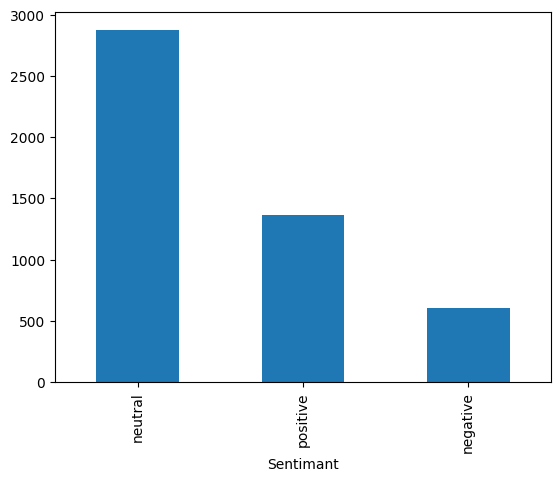

In [11]:
data['Sentimant'].value_counts().plot(kind='bar')

From this we can clearly say that data is clearly imbalance

In [12]:
data['text_length']=data['Sentence'].apply(lambda x:len(x.split()))
data['text_length'].sum()
#print("average length of the sentences:",data['text_length'].mean())

111948

In [13]:
data['text_length'].describe()

count    4846.000000
mean       23.101114
std         9.958474
min         2.000000
25%        16.000000
50%        21.000000
75%        29.000000
max        81.000000
Name: text_length, dtype: float64

The maxmium length of a sentence is 81 words 

In [14]:
data['Sentence'].duplicated().sum()

8

In the Sentences column their are 8 duplicate values

In [15]:
data.drop_duplicates(inplace=True)

In [16]:
data.duplicated().sum()

0

In [17]:
data.shape

(4840, 3)

In [18]:
#!pip install wordcloud

In [19]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english')) - {'no', 'not'} #all stop words excluding no and not
lemmatizer = WordNetLemmatizer()

In [20]:
data.columns

Index(['Sentimant', 'Sentence', 'text_length'], dtype='object')

In [21]:
def noramalize(text):
    text=text.lower()
    text=re.sub(r"http\S+|www\S+",' ',text).strip() #removes the links provided in the text
    #text=re.sub(r'\d+','',text) #removes the numbers in the sentence
    text=re.sub(r"[^a-z\s]",' ',text) #removes punctuations
    text=re.sub(r'\s+',' ',text)#removes extra spaces in the text
    return text
data['cleaned_text']=data['Sentence'].apply(noramalize)

In [22]:
from nltk.tokenize import word_tokenize

In [23]:
data['tokens']=data['cleaned_text'].apply(word_tokenize)

In [24]:
data.head()

,Sentimant,Sentence,text_length,cleaned_text,tokens
0,neutral,"According to Gran , the company has no plans t...",25,according to gran the company has no plans to ...,"[according, to, gran, the, company, has, no, p..."
1,neutral,Technopolis plans to develop in stages an area...,31,technopolis plans to develop in stages an area...,"[technopolis, plans, to, develop, in, stages, ..."
2,negative,The international electronic industry company ...,36,the international electronic industry company ...,"[the, international, electronic, industry, com..."
3,positive,With the new production plant the company woul...,33,with the new production plant the company woul...,"[with, the, new, production, plant, the, compa..."
4,positive,According to the company 's updated strategy f...,41,according to the company s updated strategy fo...,"[according, to, the, company, s, updated, stra..."


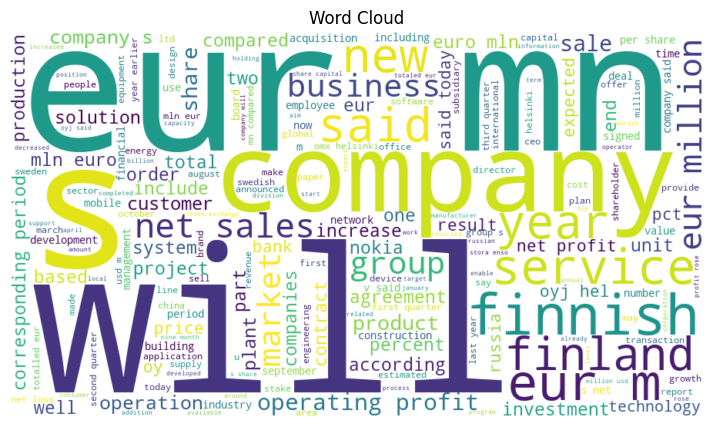

In [25]:
from wordcloud import WordCloud
def word_cloud(dframe):
    all_text=' '.join(dframe['cleaned_text'])
    wordcloud=WordCloud(width=900,height=500,background_color='white').generate(all_text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud,interpolation='bilinear')
    plt.axis('off')
    plt.title('Word Cloud')
    plt.show()
word_cloud(data)

From the word cloud we can say that eur is the most repeating important word followed by mn than will 

In [26]:
data.head()

,Sentimant,Sentence,text_length,cleaned_text,tokens
0,neutral,"According to Gran , the company has no plans t...",25,according to gran the company has no plans to ...,"[according, to, gran, the, company, has, no, p..."
1,neutral,Technopolis plans to develop in stages an area...,31,technopolis plans to develop in stages an area...,"[technopolis, plans, to, develop, in, stages, ..."
2,negative,The international electronic industry company ...,36,the international electronic industry company ...,"[the, international, electronic, industry, com..."
3,positive,With the new production plant the company woul...,33,with the new production plant the company woul...,"[with, the, new, production, plant, the, compa..."
4,positive,According to the company 's updated strategy f...,41,according to the company s updated strategy fo...,"[according, to, the, company, s, updated, stra..."


In [27]:
import nltk
from nltk.corpus import stopwords
#nltk.download('stopwords') #all the stopwords are stored in this 

In [28]:
stop=set(stopwords.words('english'))
data['tokens']=data['tokens'].apply(lambda words :[w for w in words if w not in stop])

In [29]:
data['processed_text'] = data['tokens'].apply(lambda x: " ".join(x))

In [30]:
from collections import Counter

The following are the top 10 words in neutral sentiment

In [31]:
data.head()

,Sentimant,Sentence,text_length,cleaned_text,tokens,processed_text
0,neutral,"According to Gran , the company has no plans t...",25,according to gran the company has no plans to ...,"[according, gran, company, plans, move, produc...",according gran company plans move production r...
1,neutral,Technopolis plans to develop in stages an area...,31,technopolis plans to develop in stages an area...,"[technopolis, plans, develop, stages, area, le...",technopolis plans develop stages area less squ...
2,negative,The international electronic industry company ...,36,the international electronic industry company ...,"[international, electronic, industry, company,...",international electronic industry company elco...
3,positive,With the new production plant the company woul...,33,with the new production plant the company woul...,"[new, production, plant, company, would, incre...",new production plant company would increase ca...
4,positive,According to the company 's updated strategy f...,41,according to the company s updated strategy fo...,"[according, company, updated, strategy, years,...",according company updated strategy years baswa...


In [32]:
import seaborn as sns

In [33]:
def plot_word_frequency_by_sentiment(df, sentiment, num_words):
    # Filter tokens based on the given sentiment
    sentiment_tokens = df[df['Sentimant'] == sentiment]['tokens']

    # Flatten the list of tokens
    all_words = [word for tokens in sentiment_tokens for word in tokens]

    # Count word frequencies
    word_counts = Counter(all_words)
    common_words = word_counts.most_common(num_words)

    # Separate words and counts for plotting
    words, counts = zip(*common_words)

    # Plot word frequencies
    plt.figure(figsize=(10, 8))
    sns.barplot(x=list(counts), y=list(words), palette='viridis')
    plt.title(f'Top {num_words} Most Frequent Words for {sentiment.capitalize()} Sentiment')
    plt.xlabel('Frequency')
    plt.ylabel('Words')

    plt.tight_layout()
    plt.show()

C:\Users\kisho\AppData\Local\Temp\ipykernel_2736\3105103804.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


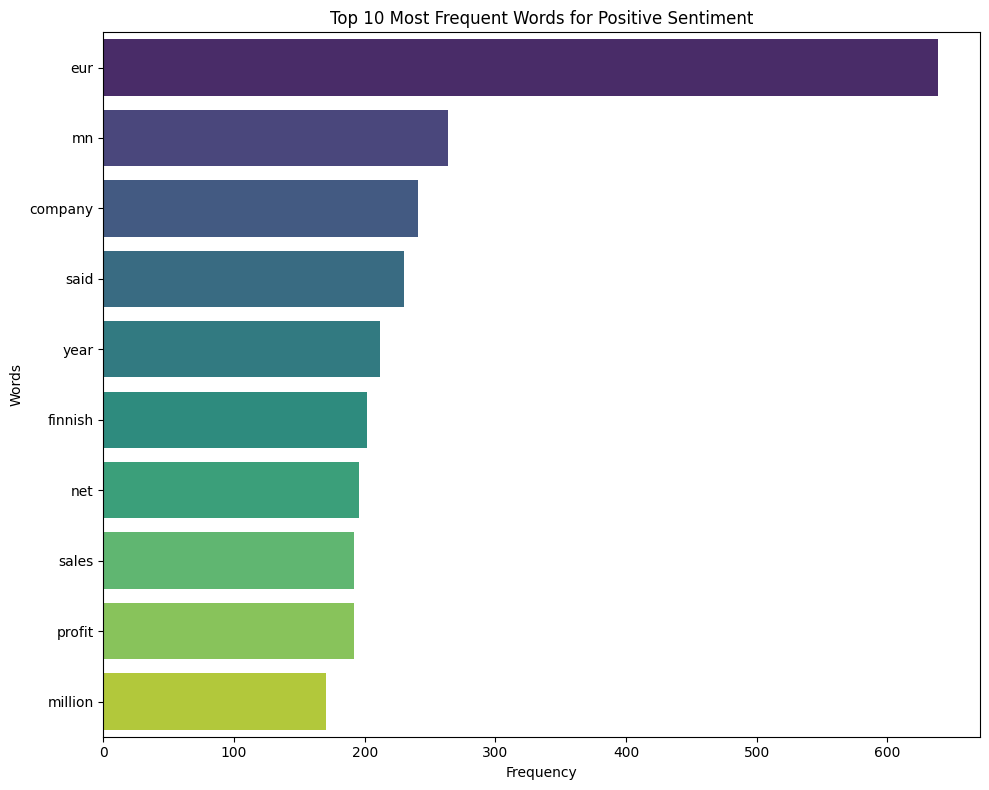

In [34]:
plot_word_frequency_by_sentiment(data, 'positive', 10)

The above are the top 10 words in positive sentiment

C:\Users\kisho\AppData\Local\Temp\ipykernel_2736\3105103804.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


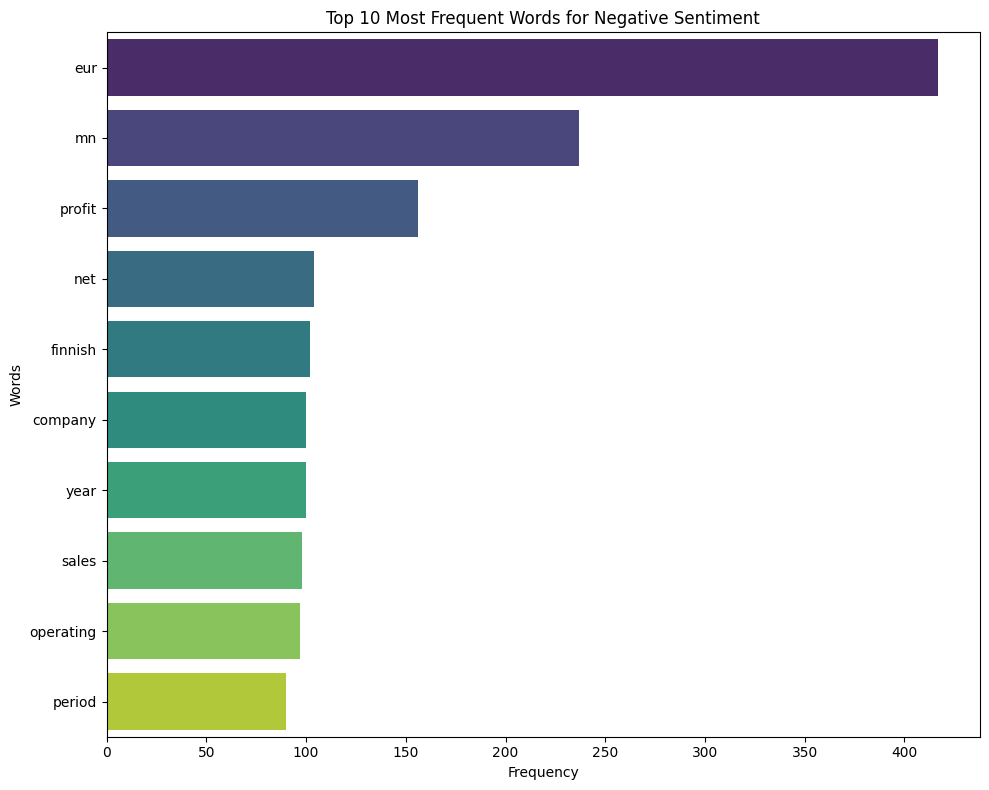

In [35]:
plot_word_frequency_by_sentiment(data, 'negative', 10)

The above are the top 10 negative words

C:\Users\kisho\AppData\Local\Temp\ipykernel_2736\3105103804.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


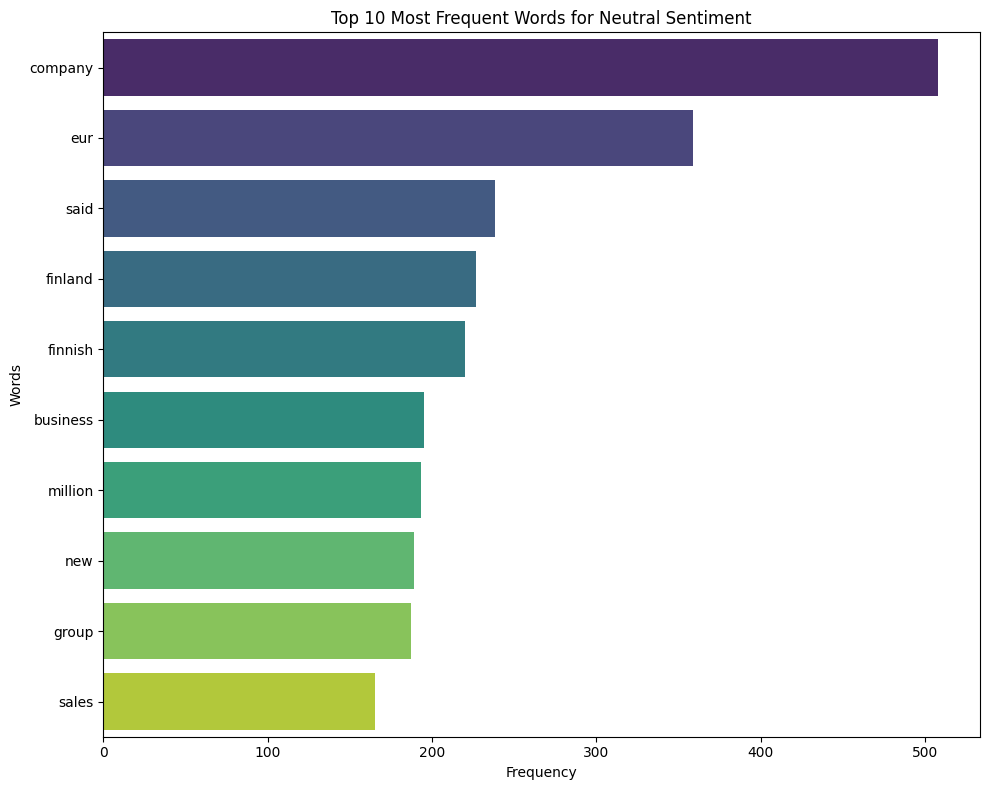

In [36]:
plot_word_frequency_by_sentiment(data, 'neutral', 10)

The above are the top 10 neutral words

C:\Users\kisho\AppData\Local\Temp\ipykernel_2736\2767888195.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='ngram', data=top_ngrams, palette='plasma')


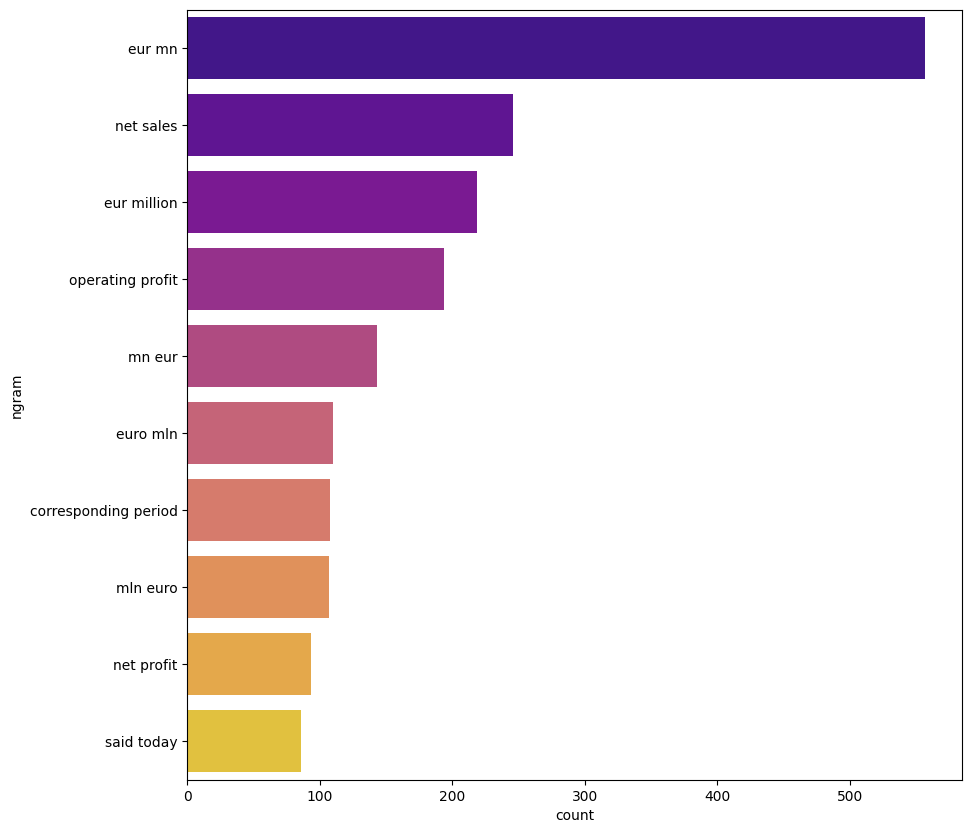

In [37]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(corpus, ngram_range=(2, 2), num_ngrams=10):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(corpus)
    ngram_counts = X.sum(axis=0).A1
    ngram_names = vectorizer.get_feature_names_out()

    ngrams_df = pd.DataFrame({'ngram': ngram_names, 'count': ngram_counts})
    top_ngrams = ngrams_df.nlargest(num_ngrams, 'count')

    plt.figure(figsize=(10,10))
    sns.barplot(x='count', y='ngram', data=top_ngrams, palette='plasma')

corpus = data['processed_text'].tolist()
plot_top_ngrams(corpus, ngram_range=(2, 2))  

The above are the top 10 bigrams in the data

C:\Users\kisho\AppData\Local\Temp\ipykernel_2736\3794695416.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='count', y='ngram', data=top_ngrams, palette='plasma')


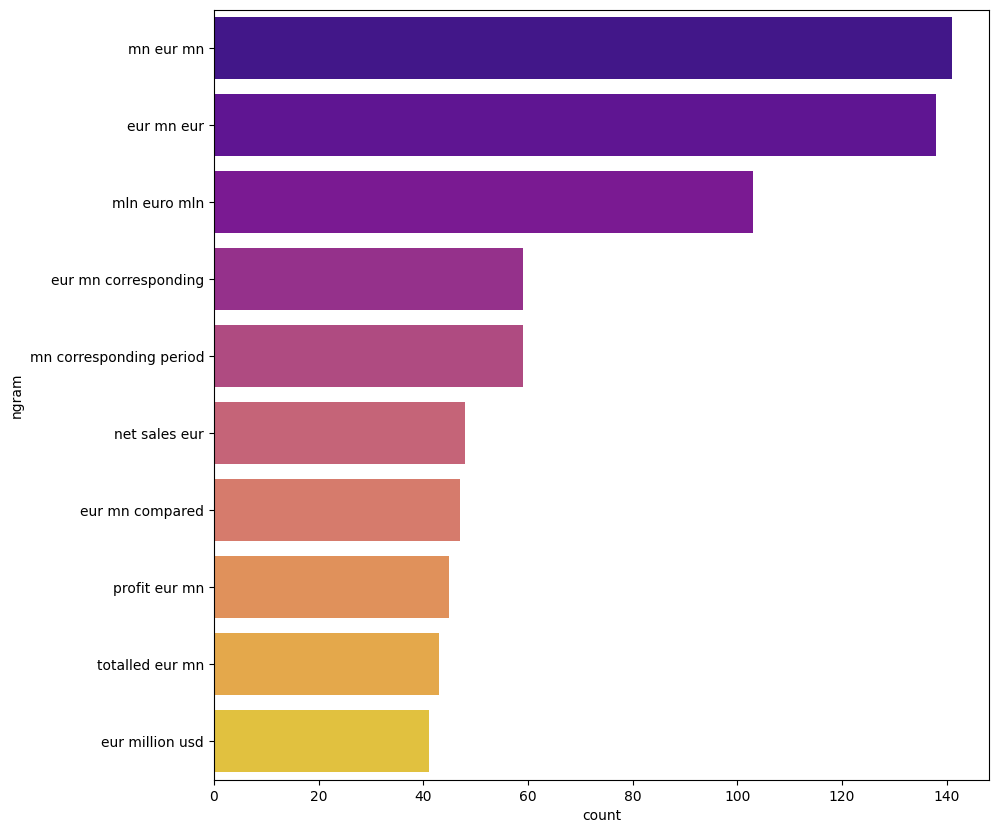

In [38]:
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(corpus, ngram_range, num_ngrams=10):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(corpus)
    ngram_counts = X.sum(axis=0).A1
    ngram_names = vectorizer.get_feature_names_out()

    ngrams_df = pd.DataFrame({'ngram': ngram_names, 'count': ngram_counts})
    top_ngrams = ngrams_df.nlargest(num_ngrams, 'count')

    plt.figure(figsize=(10,10))
    sns.barplot(x='count', y='ngram', data=top_ngrams, palette='plasma')

corpus = data['processed_text'].tolist()
plot_top_ngrams(corpus, ngram_range=(3, 3))  

Top 10 tri grams in the data

almost for every tri gram eur is present 

In [39]:
data.head()

,Sentimant,Sentence,text_length,cleaned_text,tokens,processed_text
0,neutral,"According to Gran , the company has no plans t...",25,according to gran the company has no plans to ...,"[according, gran, company, plans, move, produc...",according gran company plans move production r...
1,neutral,Technopolis plans to develop in stages an area...,31,technopolis plans to develop in stages an area...,"[technopolis, plans, develop, stages, area, le...",technopolis plans develop stages area less squ...
2,negative,The international electronic industry company ...,36,the international electronic industry company ...,"[international, electronic, industry, company,...",international electronic industry company elco...
3,positive,With the new production plant the company woul...,33,with the new production plant the company woul...,"[new, production, plant, company, would, incre...",new production plant company would increase ca...
4,positive,According to the company 's updated strategy f...,41,according to the company s updated strategy fo...,"[according, company, updated, strategy, years,...",according company updated strategy years baswa...


In [40]:
import re

# Look at examples of numbers providing key context
examples_pos = df[df['Sentimant'] == 'positive']['Sentence'].sample(5, random_state=42).tolist()
examples_neg = df[df['Sentimant'] == 'negative']['Sentence'].sample(5, random_state=42).tolist()
print("Positive examples:")
for e in examples_pos:
    print("-", e)
print("\nNegative examples:")
for e in examples_neg:
    print("-", e)

# Token length stats (word level)
df['word_len'] = df['Sentence'].apply(lambda x: len(x.split()))
print("\nWord length percentiles:")
print(df['word_len'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

Positive examples:
- The new agreement , which expands a long-established cooperation between the companies , involves the transfer of certain engineering and documentation functions from Larox to Etteplan .
- ( ADP News ) - Finnish handling systems provider Cargotec Oyj ( HEL : CGCBV ) announced on Friday it won orders worth EUR 10 million ( USD 13.2 m ) to deliver linkspans to Jordan , Morocco and Ireland .
- The world 's biggest magazine paper maker said the program to improve efficiency will include closing several of its least competitive mills and would cover all the company 's operations resulting in annual savings of some euro200 million US$ 240 million .
- a January 11 , 2010 EPHC board of directors has approved an increase in the quarterly dividend from $ 0.03 to $ 0.05 per share .
- With this appointment Kaupthing Bank aims to further co-ordinate Capital Markets activities within the Group and to improve the overall service to clients .

Negative examples:
- The company deci

In [41]:
import pandas as pd
import numpy as np

df = pd.read_csv('all-data.csv')
print(df.columns)
print(df['Sentimant'].value_counts())

# Check how numbers correlate with sentiments
df['has_number'] = df['Sentence'].str.contains(r'\d', regex=True)
df['has_percent'] = df['Sentence'].str.contains(r'%|percent', case=False, regex=True)
df['has_currency'] = df['Sentence'].str.contains(r'EUR|euro|usd|\$|mn|mln|million|billion', case=False, regex=True)

print("\n--- Presence of numbers/financial quantities by sentiment ---")
print(pd.crosstab(df['Sentimant'], df['has_number'], normalize='index') * 100)
print("\n--- Presence of % by sentiment ---")
print(pd.crosstab(df['Sentimant'], df['has_percent'], normalize='index') * 100)
print("\n--- Presence of currency/scale by sentiment ---")
print(pd.crosstab(df['Sentimant'], df['has_currency'], normalize='index') * 100)

Index(['Sentimant', 'Sentence'], dtype='object')
Sentimant
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64

--- Presence of numbers/financial quantities by sentiment ---
has_number      False      True 
Sentimant                       
negative    24.668874  75.331126
neutral     53.351858  46.648142
positive    42.333089  57.666911

--- Presence of % by sentiment ---
has_percent      False      True 
Sentimant                        
negative     85.430464  14.569536
neutral      94.755123   5.244877
positive     86.280264  13.719736

--- Presence of currency/scale by sentiment ---
has_currency      False      True 
Sentimant                         
negative      52.483444  47.516556
neutral       81.590830  18.409170
positive      63.903155  36.096845


we had observed that numbers also play a crucial role as it a financial data so i need not removed the numbers

In [42]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(data['Sentimant'])
weights = compute_class_weight(class_weight='balanced', classes=classes, y=data['Sentimant'])
class_weights_dict = dict(zip(classes, weights))

In [43]:
print(class_weights_dict)

{'negative': 2.671081677704194, 'neutral': 0.5615500638125073, 'positive': 1.1836634874052336}
